# Splice-site motif relative position density plots

This notebook generates density plots of motif relative positions to RBP binding sites from precomputed `.txt` files.

The workflow is as follows:

**AGres vs GTres**: For each RBP_CELL pair, select the motif specified in an Excel sheet, and plot **3'SS (AGres)** vs **5'SS (GTres)** densities side-by-side.

Input file format (required)
- Each `*_relative_positions.txt` is **comma-separated**, with **at least 3 rows**:
  - Row 1: distances for motif `AGGU`
  - Row 2: distances for motif `UGUGU`
  - Row 3: distances for motif `AGG`
- Values are integers (bp), typically within [-60, 60].

Outputs
- PDF figures saved to the specified output folder(s).
- The notebook also shows quick sanity checks (head, row counts, NA checks).

This notebook is a split-out, self-contained reproduction of one workflow from the original `splice_related.ipynb`.
All shared setup cells are duplicated here so you can run it independently from a fresh kernel.

In [1]:
# =========================================================
# 0) Setup: libraries + global options
# =========================================================

suppressPackageStartupMessages({
  library(ggplot2)
  library(readr)      # fast reading of delimited text
  library(stringr)    # string helpers
  library(fs)         # filesystem helpers
  library(patchwork)  # combine plots
  library(readxl)     # read Excel mapping table
})

# A small helper: create directory if missing
ensure_dir <- function(dir_path) {
  if (!dir_exists(dir_path)) {
    dir_create(dir_path, recurse = TRUE)
  }
  invisible(dir_path)
}

sessionInfo()


R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 20.04.4 LTS

Matrix products: default
BLAS/LAPACK: /fs1/private/user/wangyubo/softwares/anaconda3/envs/R-circos/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] readxl_1.4.3    patchwork_1.3.0 fs_1.6.5        stringr_1.5.1  
[5] readr_2.1.5     ggplot2_3.5.2  

loaded via a namespace (and not attached):
 [1] gtable_0.3.6      jsonlite_2.0.0    dplyr_1.1.

## Font note (Calibri and "editable text" in PDF)

If you need **editable text** in the exported PDF:
- Prefer `device = cairo_pdf` in `ggsave()`.
- Avoid `showtext_auto()` when possible (it may convert text to outlines/paths).
- Make sure your system can find Calibri via fontconfig; otherwise, choose a similar font (e.g., Arial).

In the code below, we **do not enable showtext** by default.
If Calibri is not available, the plot will fall back to another font family.


In [2]:
# =========================================================
# 1) Config: input/output paths + plot parameters
# =========================================================

# ---- Root data directory (edit if needed) ----
data_root <- "/home/wangyubo/code/BRIDGE_analysis/motif_construction/result/splicesite_RBPmotif/data"

# Workflow 1: 51st_RBPbindingsite_res
dir_51st <- file.path(data_root, "51st_RBPbindingsite_res")
out_51st <- file.path("/home/wangyubo/code/BRIDGE_analysis/motif_construction/result/splicesite_RBPmotif/fig",
                      "51st_RBPbindingsite_res")
ensure_dir(out_51st)

# AGres vs GTres
dir_ag <- file.path(data_root, "AGres")
dir_gt <- file.path(data_root, "GTres")
out_aggt <- file.path("/home/wangyubo/code/BRIDGE_analysis/motif_construction/result/splicesite_RBPmotif/fig",
                      "AG_GT_res")
ensure_dir(out_aggt)

# Excel mapping (edit if needed)
excel_map_path <- "/home/wangyubo/code/BRIDGE_analysis/motif_construction/result/splicesite_RBPmotif/AG-GU.xlsx"
excel_sheet <- 2

# ---- Plot parameters ----
xlim_51st <- c(-60, 60)
xlim_aggt <- c(-50, 50)

base_family <- "Calibri"   # If not installed, will fallback
dpi_pdf <- 300


In [3]:
# =========================================================
# 2) IO helper: read relative position matrix from txt
# =========================================================

#' Read a comma-separated relative-position file (>= 3 rows).
#'
#' Expected input format
#' - File name: "*_relative_positions.txt" (name is not strictly required)
#' - Delimiter: comma (",")
#' - Rows:
#'   1) AGGU distances
#'   2) UGUGU distances
#'   3) AGG distances
#'
#' @param file_path Character. Path to one `*_relative_positions.txt`.
#' @param n_rows Integer. Minimum number of rows required (default = 3).
#' @return A numeric matrix with rows as motifs and columns as observations.
#'         Row names are c("AGGU","UGUGU","AGG") for the first 3 rows.
#' @examples
#' mat <- read_relative_positions("/path/BUD13_K562_relative_positions.txt")
#' mat[1, 1:10]
read_relative_positions <- function(file_path, n_rows = 3) {
  stopifnot(is.character(file_path), length(file_path) == 1)

  if (!file.exists(file_path)) {
    stop("File not found: ", file_path)
  }

  # Read as comma-separated, no header
  df <- readr::read_csv(
    file = file_path,
    col_names = FALSE,
    show_col_types = FALSE,
    progress = FALSE
  )

  if (nrow(df) < n_rows) {
    stop("Invalid file (need >= ", n_rows, " rows): ", file_path,
         "\nActual rows: ", nrow(df))
  }

  # Convert to matrix WITHOUT changing shape
  mat_chr <- as.matrix(df)           # character matrix
  mat_num <- suppressWarnings(matrix(
    as.numeric(mat_chr),
    nrow = nrow(mat_chr),
    ncol = ncol(mat_chr),
    byrow = FALSE
  ))

  # Assign row names safely (only if row count matches)
  rn <- rep("", nrow(mat_num))
  rn[1:3] <- c("AGGU", "UGUGU", "AGG")
  rownames(mat_num) <- rn

  return(mat_num)
}

In [4]:
# =========================================================
# 3) Sanity check: inspect one file
# =========================================================

example_file <- file.path(dir_51st, "BUD13_K562_relative_positions.txt")
mat_ex <- read_relative_positions(example_file)

# View basic stats
cat("File:", example_file, "\n")
cat("Dim:", dim(mat_ex)[1], "rows x", dim(mat_ex)[2], "cols\n\n")

# Show first few values of each motif row
print(mat_ex[1:3, 1:12, drop = FALSE])

# NA count check
cat("\nNA counts by row:\n")
print(rowSums(is.na(mat_ex[1:3, , drop = FALSE])))


Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


File: /home/wangyubo/code/BRIDGE_analysis/motif_construction/result/splicesite_RBPmotif/data/51st_RBPbindingsite_res/BUD13_K562_relative_positions.txt 
Dim: 7 rows x 2058 cols

      [,1] [,2] [,3] [,4] [,5] [,6] [,7] [,8] [,9] [,10] [,11] [,12]
AGGU    44   22   -3   48  -12  -12   48   -6  -24   -33   -44     5
UGUGU  -15  -22  -38    7    7    7    6   22  -22   -32    39   -33
AGG    -42  -48   23  -40   44  -45   28   22  -24    -3    48     9

NA counts by row:
 AGGU UGUGU   AGG 
    0  1566     0 


In [5]:
# =========================================================
# 4) Plot helper: 3 motifs in one density plot
# =========================================================

#' Build a 3-motif density plot for one RBP_CELL file.
#'
#' @param mat Numeric matrix. Output of `read_relative_positions()`.
#' @param title Character. Plot title shown at top.
#' @param xlim Numeric length-2. x-axis limits (bp).
#' @param base_family Character. Font family name (e.g., "Calibri").
#' @return A ggplot object.
make_density_plot_three_motifs <- function(mat, title, xlim = c(-60, 60), base_family = "Calibri") {
  # Ensure we have at least 3 rows
  if (nrow(mat) < 3) stop("Input matrix must have >= 3 rows.")

  df <- data.frame(
    distance = c(mat["AGGU", ], mat["UGUGU", ], mat["AGG", ]),
    motif = rep(c("AGGU", "UGUGU", "AGG"), times = c(ncol(mat), ncol(mat), ncol(mat)))
  )

  # Remove NA safely
  df <- df[!is.na(df$distance), , drop = FALSE]

  ggplot(df, aes(x = distance, color = motif)) +
    geom_density(linewidth = 1) +
    geom_vline(xintercept = 0, color = "#adb6b6", linetype = "dashed", linewidth = 1) +
    labs(x = "", y = "Density", title = title) +
    scale_x_continuous(limits = xlim) +
    scale_color_manual(values = c("AGGU" = "#c3b4d7", "UGUGU" = "#9dc9e0", "AGG" = "#95af90")) +
    theme_minimal(base_family = base_family) +
    theme(
      panel.grid = element_blank(),
      axis.line = element_line(color = "black"),
      axis.ticks = element_line(color = "black"),
      plot.title = element_text(hjust = 0.5),
      panel.background = element_rect(fill = "white", color = NA)
    ) +
    guides(color = guide_legend(title = "Motif"))
}


## Workflow 2: comparative analysis of 3'SS vs 5'SS motif positioning

This workflow focuses on a **paired comparison** between motifs associated with
the **3' splice site (3'SS)** and the **5' splice site (5'SS)**, relative to
RBP binding sites.

Instead of visualizing all motifs simultaneously, we **select one biologically
relevant motif per RBP–cell-line pair** and directly compare its spatial
distribution at the two splice sites.

---

### Biological motivation

Pre-mRNA splicing is an inherently **asymmetric process**:

- The **5' splice site (5'SS)** is recognized early by U1 snRNP and associated factors
- The **3' splice site (3'SS)** involves branch point recognition, polypyrimidine tract binding,
  and U2/U2AF-dependent assembly

RNA-binding proteins (RBPs) can:

- preferentially bind near one splice site
- exhibit different positional constraints at 3'SS vs 5'SS
- play distinct regulatory roles depending on splice-site context

Therefore, **directly contrasting the same motif at 3'SS and 5'SS** provides
insight into:

- splice-site–specific RBP–motif coupling
- asymmetric regulatory mechanisms
- potential functional specialization of RBPs in splice-site recognition

---

### Input data organization

This workflow assumes two parallel directories:

`AGres/ → relative positions of motifs near 3' splice sites`

`GTres/ → relative positions of motifs near 5' splice sites`


For each RBP–cell-line pair:

- Both directories contain a file named  
  `RBP_CELL_relative_positions.txt`
- Each file follows the same row convention:
  - Row 1: AGGU
  - Row 2: UGUGU
  - Row 3: AGG

An external Excel table is used to map:

- `RBP_CELL` → **the motif of interest**

This design allows **RBP-specific motif selection** rather than enforcing
a one-size-fits-all motif across all RBPs.

---

### Computational strategy

For each RBP–cell-line pair:

1. Identify the motif specified in the Excel mapping table
2. Extract the corresponding distance vector from:
   - AGres (3'SS)
   - GTres (5'SS)
3. Construct two density plots using identical:
   - x-axis limits
   - kernel density settings
   - theme and scaling
4. Arrange the two plots **side by side** for direct visual comparison
5. Save the combined figure as a vector PDF

By enforcing identical visualization parameters, observed differences between
3'SS and 5'SS reflect **biological signal rather than plotting artifacts**.

---

### Output interpretation

Each output figure represents **one RBP–cell-line pair** and one selected motif:

- Left panel: motif distribution relative to the **3' splice site**
- Right panel: motif distribution relative to the **5' splice site**

Key patterns to examine include:

- peak enrichment positions
- symmetry or skewness around the splice site
- differences in spread or sharpness of density curves

Together, these comparisons reveal **splice-site–specific positional preferences**
of RBP-associated motifs.

---

In [6]:
# =========================================================
# 6) Load Excel mapping and validate
# =========================================================

motif_map <- readxl::read_excel(excel_map_path, sheet = excel_sheet)

# Standardize column names
colnames(motif_map) <- c("RBP_CELL", "Motif")

# Basic checks
stopifnot(all(c("RBP_CELL", "Motif") %in% colnames(motif_map)))

# Keep only supported motifs
supported_motifs <- c("AGGU", "UGUGU", "AGG")
motif_map <- motif_map[motif_map$Motif %in% supported_motifs, , drop = FALSE]

cat("Mapping rows:", nrow(motif_map), "\n")
print(head(motif_map, 10))


Mapping rows: 10 
# A tibble: 10 × 2
   RBP_CELL      Motif
   <chr>         <chr>
 1 HNRNPA1_HepG2 AGG  
 2 TAF15_HepG2   AGG  
 3 GRWD1_HepG2   AGG  
 4 SAFB2_K562    AGG  
 5 DKC1_HepG2    UGUGU
 6 TARDBP_K562   UGUGU
 7 CSTF2_HEK293  UGUGU
 8 ZRANB2_K562   AGGU 
 9 FAM120A_HepG2 AGGU 
10 BUD13_K562    AGGU 


In [7]:
# =========================================================
# 7) Plot helper: single motif density panel
# =========================================================

#' Create a single density plot panel for one vector of distances.
#'
#' @param distances Numeric vector of distances (bp).
#' @param xlim Numeric length-2. x-axis limits.
#' @param line_color Character. Line color hex.
#' @param base_family Character. Font family.
#' @return ggplot object (no legend, minimal axes labels).
make_single_density_panel <- function(distances,
                                      xlim = c(-50, 50),
                                      line_color = "#000000",
                                      base_family = "Calibri") {
  df <- data.frame(distance = as.numeric(distances))
  df <- df[!is.na(df$distance), , drop = FALSE]

  ggplot(df, aes(x = distance)) +
    geom_vline(xintercept = 0, color = "#e9e9e6", linetype = "dashed", linewidth = 1) +
    geom_density(color = line_color, linewidth = 1) +
    scale_x_continuous(limits = xlim) +
    labs(x = "", y = "") +
    theme_minimal(base_family = base_family) +
    theme(
      panel.grid = element_blank(),
      axis.line = element_line(color = "black"),
      axis.ticks = element_line(color = "black"),
      plot.title = element_text(hjust = 0.5, face = "bold"),
      axis.text = element_text(size = 8),
      panel.background = element_rect(fill = "white", color = NA),
      legend.position = "none"
    )
}


Found 7 AGres files.


Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“Removed 13 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font fa

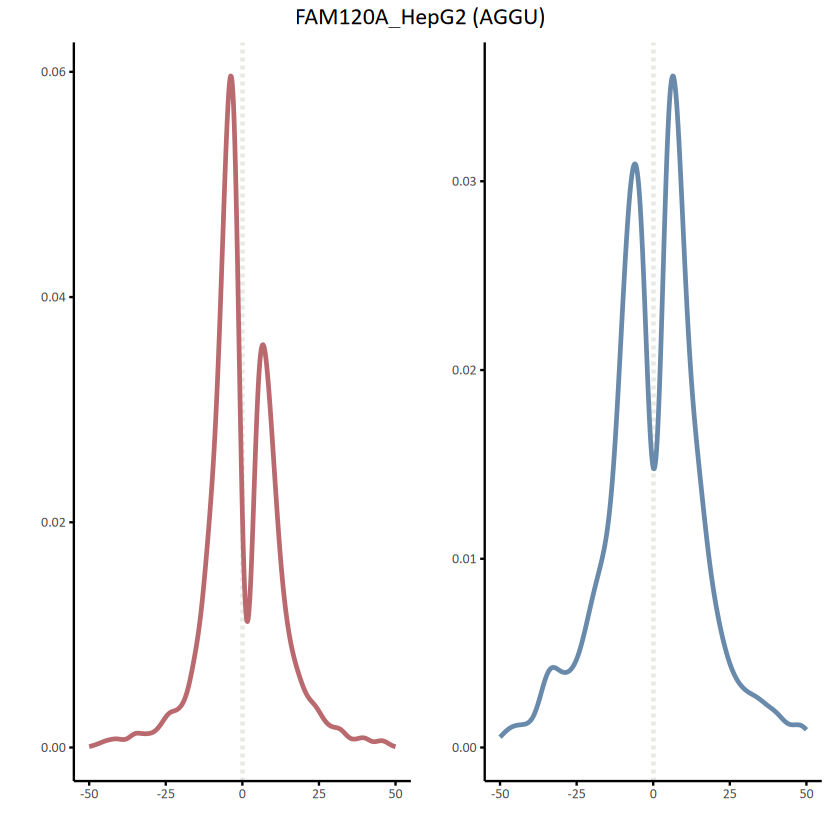

Saved: /home/wangyubo/code/BRIDGE_analysis/motif_construction/result/splicesite_RBPmotif/fig/AG_GT_res/GRWD1_HepG2.pdf

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“Removed 31 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label),

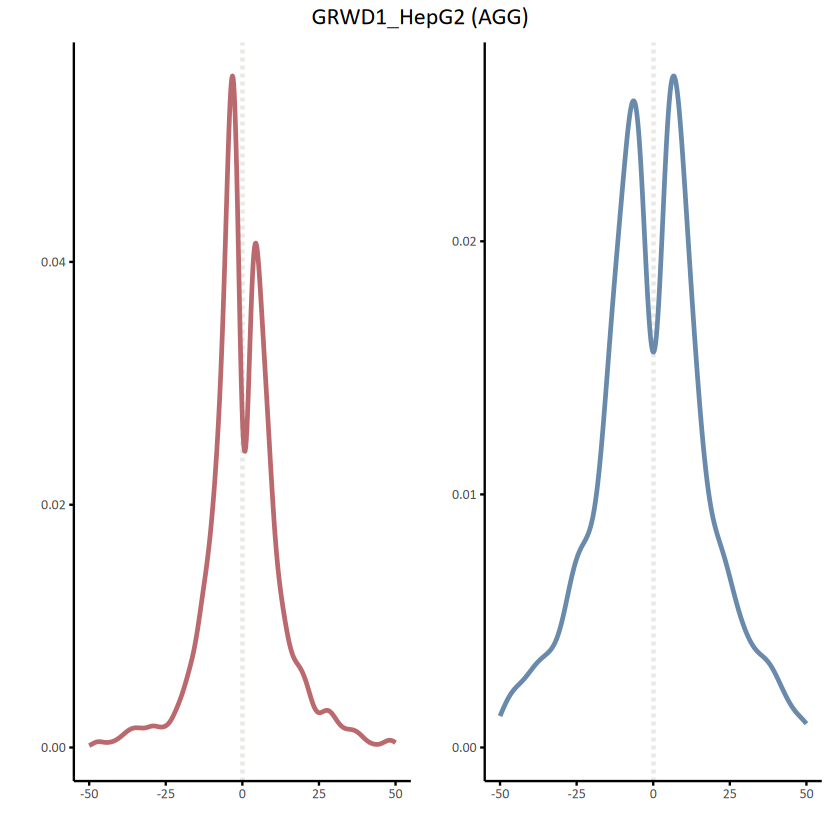

Saved: /home/wangyubo/code/BRIDGE_analysis/motif_construction/result/splicesite_RBPmotif/fig/AG_GT_res/HNRNPA1_HepG2.pdf

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“Removed 27 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label

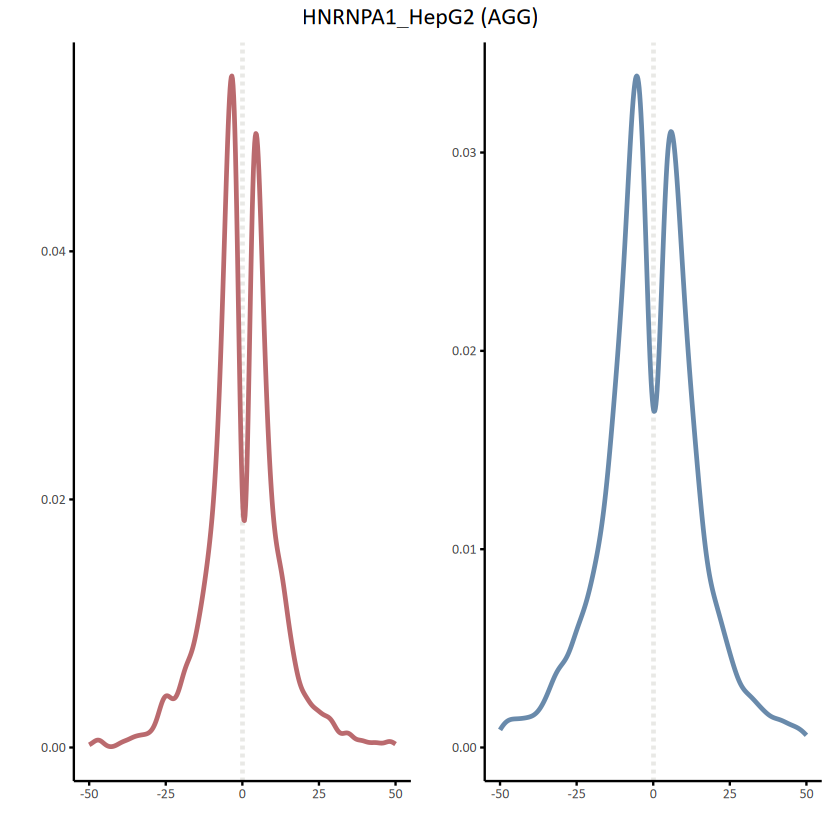

Saved: /home/wangyubo/code/BRIDGE_analysis/motif_construction/result/splicesite_RBPmotif/fig/AG_GT_res/SAFB2_K562.pdf

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“Removed 43 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), 

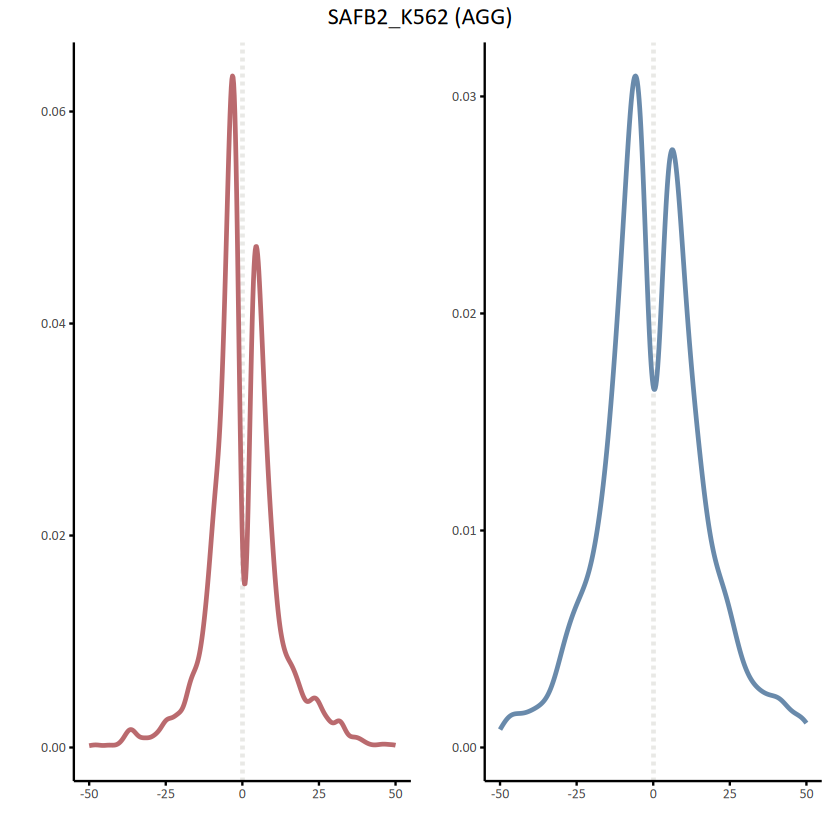

Saved: /home/wangyubo/code/BRIDGE_analysis/motif_construction/result/splicesite_RBPmotif/fig/AG_GT_res/TAF15_HepG2.pdf

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“Removed 36 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label),

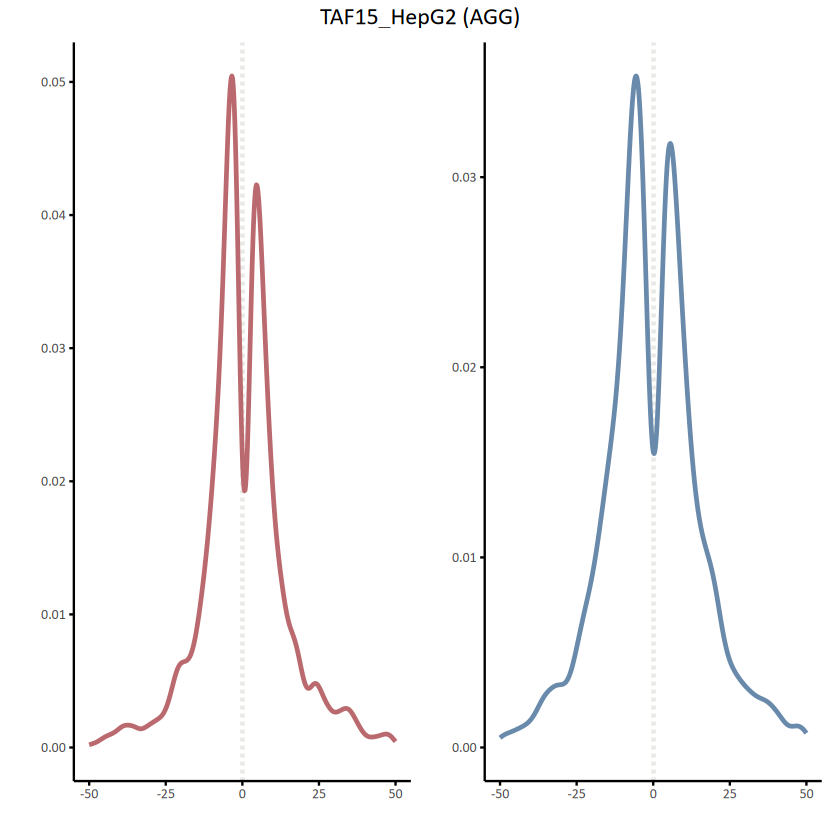

Saved: /home/wangyubo/code/BRIDGE_analysis/motif_construction/result/splicesite_RBPmotif/fig/AG_GT_res/TARDBP_K562.pdf

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“Removed 24 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Calibri' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label),

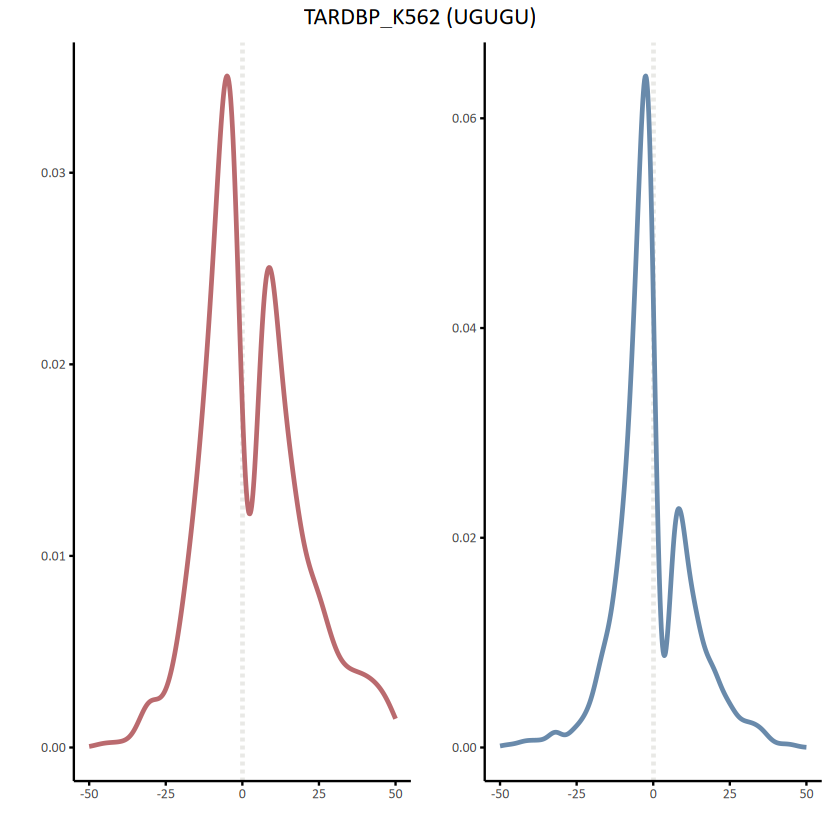

Saved: /home/wangyubo/code/BRIDGE_analysis/motif_construction/result/splicesite_RBPmotif/fig/AG_GT_res/ZRANB2_K562.pdf



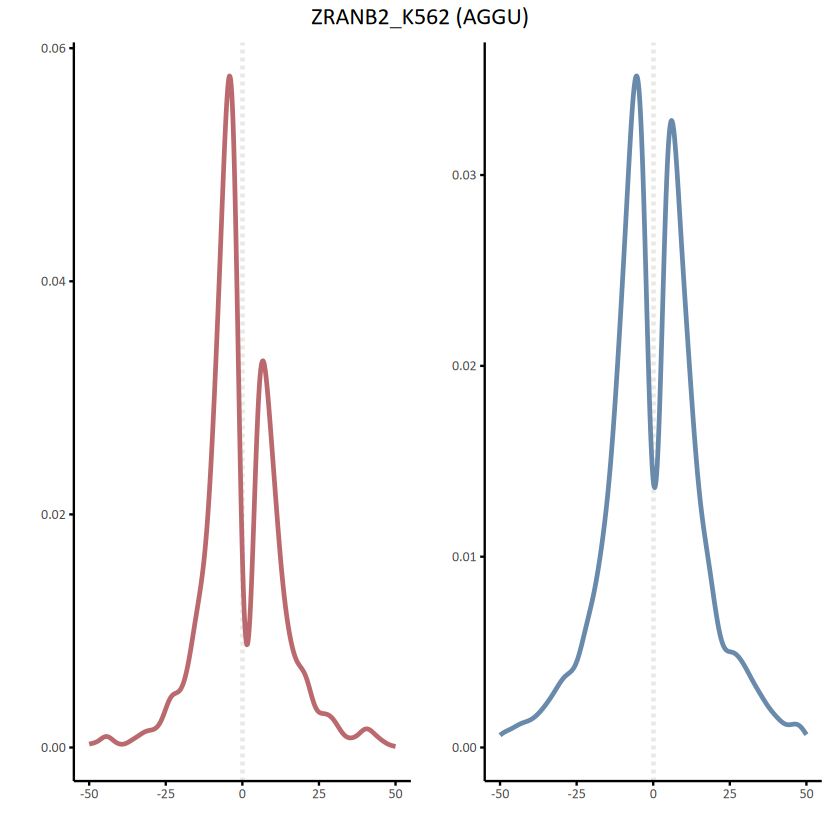

In [8]:
# =========================================================
# 8) batch plot AGres vs GTres (motif selected by mapping)
# =========================================================

# Get AGres files (as "keys")
files_ag <- dir_ls(dir_ag, regexp = ".*_relative_positions\\.txt$", type = "file")

exclude <- c(
  "CSTF2_HEK293_relative_positions.txt",
  "BUD13_K562_relative_positions.txt",
  "DKC1_HepG2_relative_positions.txt"
)

files_ag <- files_ag[!basename(files_ag) %in% exclude]
cat("Found", length(files_ag), "AGres files.\n")

for (file_ag in files_ag) {
  rbp_cell <- str_replace(basename(file_ag), "_relative_positions\\.txt$", "")

  # Find matching GTres file
  file_gt <- file.path(dir_gt, paste0(rbp_cell, "_relative_positions.txt"))
  if (!file_exists(file_gt)) {
    message("Skipping (GT file not found): ", rbp_cell)
    next
  }

  # Find motif for this RBP_CELL
  motif <- motif_map$Motif[motif_map$RBP_CELL == rbp_cell]
  if (length(motif) == 0) {
    message("Skipping (motif not found in Excel): ", rbp_cell)
    next
  }
  motif <- motif[1]

  # Read matrices
  mat_ag <- read_relative_positions(file_ag)
  mat_gt <- read_relative_positions(file_gt)

  # Extract selected motif row
  if (!(motif %in% rownames(mat_ag)) || !(motif %in% rownames(mat_gt))) {
    message("Skipping (motif row missing): ", rbp_cell, " motif=", motif)
    next
  }

  dist_ag <- mat_ag[motif, ]
  dist_gt <- mat_gt[motif, ]

  # Two panels: left=3'SS(AGres), right=5'SS(GTres)
  p_left <- make_single_density_panel(
    distances = dist_ag,
    xlim = xlim_aggt,
    line_color = "#ba6a6e",
    base_family = base_family
  )

  p_right <- make_single_density_panel(
    distances = dist_gt,
    xlim = xlim_aggt,
    line_color = "#698aab",
    base_family = base_family
  )

  # Combine with patchwork; title is rbp_cell (and optionally motif)
  p_combined <- p_left + p_right +
    plot_annotation(
      title = paste0(rbp_cell, " (", motif, ")"),
      theme = theme(plot.title = element_text(family = base_family, face = "bold", size = 14, hjust = 0.5))
    )
  print(p_combined)
  out_pdf <- file.path(out_aggt, paste0(rbp_cell, ".pdf"))
  ggsave(
    filename = out_pdf,
    plot = p_combined,
    width = 8, height = 4,
    device = cairo_pdf
  )

  message("Saved: ", out_pdf)
}


## Troubleshooting

1) **`read_csv()` reads only 1 row / weird columns**
- Confirm the file is comma-separated, not tab-separated.
- Try: `readLines(file, n = 3)` to inspect the raw text.

2) **Fonts not editable in PDF**
- Avoid `showtext_auto()`.
- Use `device = cairo_pdf`.
- Ensure Calibri exists in Linux fontconfig (`fc-list | grep -i calibri`).

3) **NA values present**
- The code drops NA before plotting.
- If too many NAs, check if the file contains empty trailing commas.
